In [1]:
import numpyro
import pandas as pd

/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# pip install jax jaxlib numpyro
import jax
import jax.numpy as jnp
from jax import random, lax
from numpyro import sample, plate, deterministic
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

# ===========================
# Utilities
# ===========================
def fourier_features(T: int, period: float = 12.0, K: int = 5):
    """(T, 2K) のフーリエ基底（cos, sin を n=1..K）"""
    t = jnp.arange(T, dtype=jnp.float32)
    cols = []
    for n in range(1, K + 1):
        cols.append(jnp.cos(2.0 * jnp.pi * n * t / period))
        cols.append(jnp.sin(2.0 * jnp.pi * n * t / period))
    X = jnp.stack(cols, axis=1)  # (T, 2K)
    return X

def bass_sales_series(p: float, q: float, m: float, T: int):
    """
    離散 Bass:
      s_t = m * (p + q*F_t) * (1 - F_t)
      F_{t+1} = F_t + s_t / m
    戻り値: s (T,)
    """
    def step(F_t, _):
        s_t = m * (p + q * F_t) * (1.0 - F_t)
        F_next = F_t + s_t / m
        return F_next, s_t
    F0 = 0.0
    _, s = lax.scan(step, F0, xs=None, length=T)
    return s

# ===========================
# NumPyro model
# ===========================
def model_bass_fourier(y, K: int = 5, period: float = 12.0,
                       p_loc= jnp.log(0.02), p_scale=0.5,
                       q_loc= jnp.log(0.30), q_scale=0.5,
                       m_loc= None, m_scale=0.8,
                       beta_scale=200.0):
    """
    y: (T,) 実測（連続量想定）
    事前分布:
      p, q, m ~ LogNormal
      alpha ~ Normal(0, 1e3)
      beta_(2K) ~ Normal(0, beta_scale)
      sigma ~ HalfNormal( scale= y.std()の素朴推定 )
    """
    T = y.shape[0]
    X = fourier_features(T, period=period, K=K)  # (T, 2K)

    # 事前（m_loc が None のときは y.sum()*1.5 を基準に設定）
    if m_loc is None:
        m0 = jnp.log(jnp.maximum(y.sum()*1.5, 1e-3))
    else:
        m0 = m_loc

    # 正値パラメータは LogNormal で
    p = sample("p", dist.LogNormal(p_loc, p_scale))
    q = sample("q", dist.LogNormal(q_loc, q_scale))
    m = sample("m", dist.LogNormal(m0, m_scale))

    # 季節
    beta = sample("beta", dist.Normal(jnp.zeros(2*K), beta_scale))
    season = deterministic("season", X @ beta)  # (T,)

    # Bass トレンド
    trend = deterministic("trend", bass_sales_series(p, q, m, T))  # (T,)

    # 切片とノイズ
    alpha = sample("alpha", dist.Normal(0.0, 1e3))
    sigma0 = jnp.maximum(jnp.std(y) * 0.5, 1e-3)
    sigma = sample("sigma", dist.HalfNormal(sigma0))

    mu = deterministic("mu", alpha + trend + season)

    with plate("time", T):
        sample("y", dist.Normal(mu, sigma), obs=y)

    # 予測用の deterministic も保持
    deterministic("yhat", mu)

In [3]:
T = 60  # 5年
true_p, true_q, true_m = 0.02, 0.35, 10000.0
X = fourier_features(T, period=12.0, K=5)
beta_true = jnp.array([
    200.,  60.,   # n=1 cos,sin
    120., -30.,   # n=2
     80.,  10.,   # n=3
     40.,  -5.,   # n=4
     20.,   0.    # n=5
], dtype=jnp.float32)
alpha_true = 50.0
key = random.PRNGKey(0)

trend_true = bass_sales_series(true_p, true_q, true_m, T)
season_true = X @ beta_true
mu_true = alpha_true + trend_true + season_true
y = mu_true + random.normal(key, (T,)) * 50.0  # 観測

# ----- Fit with NUTS -----
nuts = NUTS(model_bass_fourier, target_accept_prob=0.9, dense_mass=True)
mcmc = MCMC(nuts, num_warmup=1500, num_samples=1500, num_chains=1, progress_bar=True)

In [4]:
df = pd.read_csv("data/coolrevolution実績.csv", parse_dates=["受注_伝票登録日付"])
df = df.rename(columns={"受注_伝票登録日付": "date", "売上金額": "sales"})
df["day"] = df.date.dt.date

In [5]:
sales = df.groupby(pd.Grouper(key='date', freq='MS')).sales.sum()

In [6]:
sales

date
2020-03-01    130380000
2020-04-01     12860000
2020-05-01     22010000
2020-06-01    135790000
2020-07-01    102405000
                ...    
2025-02-01            0
2025-03-01     25730000
2025-04-01     59460000
2025-05-01     24785000
2025-06-01      1350000
Freq: MS, Name: sales, Length: 64, dtype: int64

In [23]:
p_loc = jnp.log(0.02)
q_loc = jnp.log(0.30)
m_loc = jnp.log(jnp.maximum(sales.sum()*1.5, 1e-3))

mcmc.run(
    key,
    y=sales.values,
    K=5,
    period=12.0,
    p_loc=p_loc, p_scale=0.5,
    q_loc=q_loc, q_scale=0.5,
    m_loc=m_loc, m_scale=0.8,
    beta_scale=200.0
)

sample: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:02<00:00, 1145.41it/s, 31 steps of size 1.30e-01. acc. prob=0.97]


In [24]:
mcmc.print_summary(exclude_deterministic=False)

# ----- Posterior samples -----
posterior = mcmc.get_samples()

# ----- Posterior predictive (in-sample) -----
pred = Predictive(model_bass_fourier, posterior_samples=posterior, return_sites=["yhat","trend","season","mu"])
pred_samples = pred(random.PRNGKey(1), y=sales.values, K=5, period=12.0)


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      2.56   1044.82    -19.20  -1711.49   1692.82   2566.73      1.00
   beta[0]     -2.44    208.92      0.68   -317.63    370.46   2920.08      1.00
   beta[1]     -3.86    194.27     -3.70   -326.17    310.77   2531.60      1.00
   beta[2]     -2.55    196.23     -2.25   -338.23    292.03   2594.76      1.00
   beta[3]     -7.58    196.99     -4.61   -338.13    294.84   1821.12      1.00
   beta[4]     -2.35    197.40     -0.10   -324.10    318.95   3740.60      1.00
   beta[5]      0.10    204.10      2.46   -332.96    330.71   1924.04      1.00
   beta[6]     -2.64    209.57     -5.94   -342.53    337.58   2033.14      1.00
   beta[7]      3.44    204.38      6.56   -321.63    333.44   2282.65      1.00
   beta[8]      0.72    194.82     -4.81   -314.94    325.14   2288.53      1.00
   beta[9]      0.11    204.11     -5.50   -333.00    338.26   2058.51      1.00
         m 538222592.00 197

<Axes: >

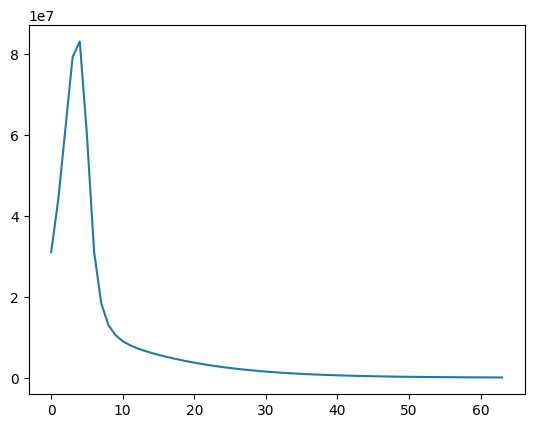

In [25]:
pd.DataFrame(pred_samples['yhat']).T.mean(axis=1).plot()

<Axes: ylabel='Frequency'>

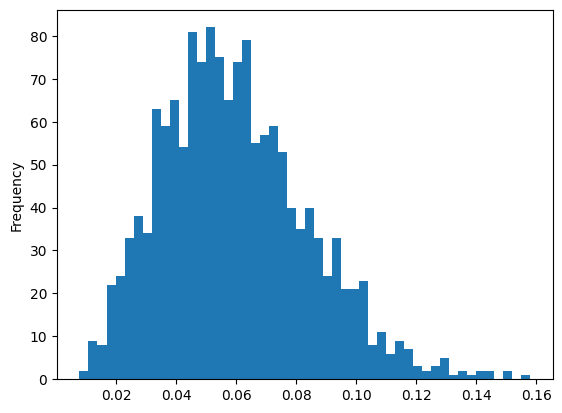

In [34]:
pd.Series(posterior['p']).plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

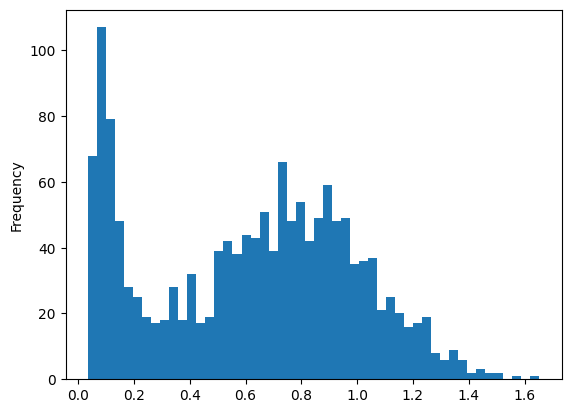

In [35]:
pd.Series(posterior['q']).plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

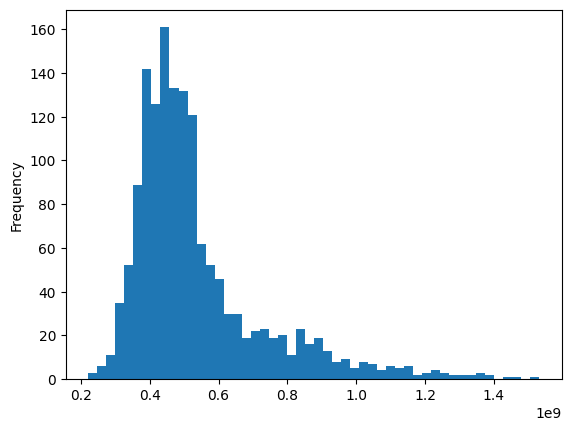

In [36]:
pd.Series(posterior['m']).plot(kind='hist', bins=50)